# 04 — Intent-tree comparison: real conversations vs. artifacts

**The thesis comparison.** DiscoverLLM builds intent trees from *synthetic artifacts* during
training. This project builds DiscoverLLM-style intent trees from *real conversations* (ThoughtTrace).
This notebook compares the two tree sources on shared structural metrics.

**Questions**

1. How do intent trees differ structurally between **artifact-derived** (DiscoverLLM baseline, NB2)
   and **real-conversation-derived** (ThoughtTrace extraction, NB3) sources?
2. nodes per tree, depth, branching factor, count per source.

**Status / caveat:** the real-conversation side currently uses only the extraction(s) under
`data/sonnet_extractions/` (proof of concept; small N). It scales automatically as more conversations
are extracted there.

## Sources & schemas

- **Artifact-derived** (baseline): official `kixlab/DiscoverLLM-multiturn-preferences`; trees parsed
  from `criteria_history → hierarchy` (nested `{id, text, children}`). Same source as NB2.
- **Real-conversation-derived** (the new method): DiscoverLLM-style extractions of ThoughtTrace
  conversations, stored as JSON under `data/sonnet_extractions/*.json`; schema `trees[]` each
  `{tree_id, intent_type, nodes[]}`, node = `{id, label, discovery_state, turn_of_discovery,
  parent_id, evidence}` (flat, parent-pointer).

Both are normalized to common metrics: **n_nodes**, **depth**, **branching** (mean children of
internal nodes).

In [1]:
import os
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

def _repo_root():
    # Marker independent of the (removed) reproduction package.
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "requirements.txt").exists() and (cand / "notebooks").is_dir():
            return cand
    return Path.cwd()

ROOT = _repo_root()
pd.set_option("display.width", 120)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Artifact-derived intent trees (baseline) from the official DiscoverLLM dataset ---
DATASET = "kixlab/DiscoverLLM-multiturn-preferences"
CONFIGS = ["creative_writing", "svg_drawing", "technical_writing"]

def iter_nested(node):
    yield node
    for c in node.get("children", []):
        yield from iter_nested(c)

def nested_depth(node):
    ch = node.get("children", [])
    return 1 if not ch else 1 + max(nested_depth(c) for c in ch)

def nested_branching(root):
    internal = [n for n in iter_nested(root) if n.get("children")]
    return round(sum(len(n["children"]) for n in internal) / len(internal), 2) if internal else 0.0

def extract_hierarchies(s):
    roots = []
    try:
        parsed = json.loads(s) if isinstance(s, str) else s
    except Exception:
        return roots
    stack, seen = [parsed], set()
    while stack:
        x = stack.pop()
        if isinstance(x, list):
            stack.extend(x)
        elif isinstance(x, dict):
            if isinstance(x.get("hierarchy"), list):
                k = str(x.get("criterion", ""))[:80]
                if k not in seen:
                    seen.add(k)
                    roots.extend(x["hierarchy"])
            for v in x.values():
                if isinstance(v, (list, dict)):
                    stack.append(v)
    return roots

art_rows = []
for cfg in CONFIGS:
    df = load_dataset(DATASET, cfg, split="train", token=os.environ.get("HF_TOKEN")).to_pandas()
    df = (df.assign(_l=df["criteria_history"].fillna("").str.len())
            .sort_values("_l", ascending=False).drop_duplicates("artifact_id"))
    for _, r in df.iterrows():
        for root in extract_hierarchies(r["criteria_history"]):
            art_rows.append({"source": "artifact (DiscoverLLM)",
                             "n_nodes": sum(1 for _ in iter_nested(root)),
                             "depth": nested_depth(root),
                             "branching": nested_branching(root)})

art = pd.DataFrame(art_rows)
print("artifact-derived trees:", len(art))
print(art[["n_nodes", "depth", "branching"]].describe())

artifact-derived trees: 8141
           n_nodes        depth    branching
count  8141.000000  8141.000000  8141.000000
mean      4.866847     2.959956     1.044379
std       5.321318     1.496061     0.585215
min       1.000000     1.000000     0.000000
25%       2.000000     2.000000     1.000000
50%       3.000000     3.000000     1.000000
75%       6.000000     4.000000     1.360000
max      42.000000     9.000000     6.000000


In [ ]:
# --- Real-conversation-derived intent trees (the new method) ---
# DiscoverLLM-style extractions of ThoughtTrace conversations: frozen Sonnet fixtures plus the
# Morpheus overnight-batch output (scripts/extract_intent_trees.py).
EXTRACTION_DIRS = [ROOT / "data" / "extractions_gpt54mini"]
files = sorted(f for d in EXTRACTION_DIRS for f in d.glob("*.json"))
print(f"extraction files: {len(files)} (dirs: {[d.name for d in EXTRACTION_DIRS]})")

def flat_metrics(nodes):
    by_id = {n["id"]: n for n in nodes}
    def node_depth(n):
        k, cur = 1, n
        while cur.get("parent_id") is not None and cur.get("parent_id") in by_id:
            cur = by_id[cur["parent_id"]]; k += 1
        return k
    childcount = Counter(n["parent_id"] for n in nodes if n.get("parent_id") is not None)
    internal = list(childcount.values())
    branching = round(sum(internal) / len(internal), 2) if internal else 0.0
    depth = max((node_depth(n) for n in nodes), default=0)
    return len(nodes), depth, branching

conv_rows = []
for f in files:
    doc = json.loads(f.read_text(encoding="utf-8"))
    for t in doc.get("trees", []):
        nodes = t.get("nodes", [])
        if not nodes:
            continue
        n, dep, br = flat_metrics(nodes)
        conv_rows.append({"source": "conversation (ThoughtTrace)", "n_nodes": n, "depth": dep, "branching": br})

conv = pd.DataFrame(conv_rows)
print("real-conversation trees:", len(conv))
if conv.empty:
    print("(no extraction files yet - run scripts/extract_intent_trees.py to populate data/extractions/)")
else:
    print(conv[["n_nodes", "depth", "branching"]].describe())
if 0 < len(conv) < 5:
    print("NOTE: very small N on the conversation side - illustrative only until more are extracted.")

extraction files: 16 (dirs: ['sonnet_extractions', 'extractions'])
real-conversation trees: 17
         n_nodes      depth  branching
count  17.000000  17.000000  17.000000
mean    4.764706   2.117647   2.284706
std     2.194579   0.857493   1.763693
min     1.000000   1.000000   0.000000
25%     3.000000   2.000000   1.000000
50%     4.000000   2.000000   2.000000
75%     6.000000   3.000000   3.000000
max     9.000000   4.000000   5.000000


                            n_nodes                  depth                  branching                  
                              count  mean median max count  mean median max     count  mean median  max
source                                                                                                 
artifact (DiscoverLLM)         8141  4.87    3.0  42  8141  2.96    3.0   9      8141  1.04    1.0  6.0
conversation (ThoughtTrace)      17  4.76    4.0   9    17  2.12    2.0   4        17  2.28    2.0  5.0


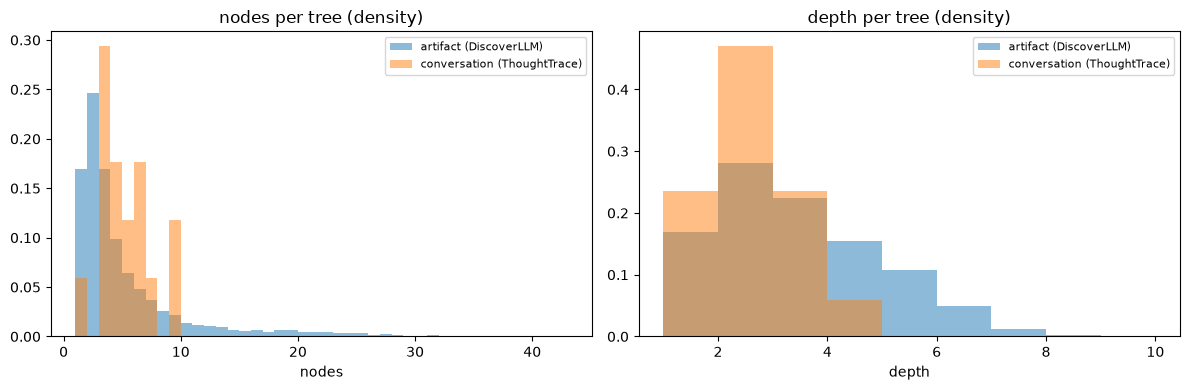

In [4]:
# --- Compare ---
both = pd.concat([art, conv], ignore_index=True)
summary = both.groupby("source")[["n_nodes", "depth", "branching"]].agg(["count", "mean", "median", "max"]).round(2)
print(summary)

if not conv.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    nmax, dmax = int(both["n_nodes"].max()), int(both["depth"].max())
    for src, sub in both.groupby("source"):
        axes[0].hist(sub["n_nodes"], bins=range(1, nmax + 2), alpha=0.5, density=True, label=src)
        axes[1].hist(sub["depth"], bins=range(1, dmax + 2), alpha=0.5, density=True, label=src)
    axes[0].set_title("nodes per tree (density)"); axes[0].set_xlabel("nodes"); axes[0].legend(fontsize=8)
    axes[1].set_title("depth per tree (density)"); axes[1].set_xlabel("depth"); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

In [5]:
# --- One example tree from each source, side by side ---
def render_nested(node, indent=0):
    pad = "    " * indent
    lines = [f"{pad}[{node.get('id')}] {node.get('text')}"]
    for c in node.get("children", []):
        lines += render_nested(c, indent + 1)
    return lines

def render_flat(nodes):
    kids = {}
    for n in nodes:
        kids.setdefault(n.get("parent_id"), []).append(n)
    def rec(n, indent=0):
        pad = "    " * indent
        lines = [f"{pad}[{n.get('id')}] {n.get('label')}  ({n.get('discovery_state', '?')})"]
        for c in kids.get(n["id"], []):
            lines += rec(c, indent + 1)
        return lines
    out = []
    for root in kids.get(None, []):   # roots: parent_id is None
        out += rec(root)
    return out

ex = load_dataset(DATASET, "creative_writing", split="train[:5]", token=os.environ.get("HF_TOKEN")).to_pandas()
print("=== artifact-derived (DiscoverLLM) example tree ===")
for _, r in ex.iterrows():
    hs = extract_hierarchies(r["criteria_history"])
    if hs:
        print("\n".join(render_nested(hs[0])))
        break

print("\n=== real-conversation (ThoughtTrace) example tree ===")
shown = False
for f in files:
    doc = json.loads(f.read_text(encoding="utf-8"))
    for t in doc.get("trees", []):
        if t.get("nodes"):
            print(f"[{f.name} | tree {t.get('tree_id')} | intent_type={t.get('intent_type')}]")
            print("\n".join(render_flat(t["nodes"])))
            shown = True
            break
    if shown:
        break

=== artifact-derived (DiscoverLLM) example tree ===
[1] First-person narrative from an insider's perspective
    [1.1] First-person narrative from a band member's perspective
        [1.1.1] Conversational, casual tone that directly addresses the reader

=== real-conversation (ThoughtTrace) example tree ===
[user1042_task1_conversation1.json | tree content | intent_type=planning]
[n1] Train travel  (discovered)
[n2] Private room accommodation  (discovered)
[n3] Minimal food budget  (discovered)


## Takeaways & next steps

- This is the **comparison scaffold**: artifact-derived intent trees (DiscoverLLM baseline) vs.
  DiscoverLLM-style trees extracted from real conversations, on shared structural metrics.
- **Caveat:** the conversation side currently has very small N (only the extraction(s) in
  `data/sonnet_extractions/`). Treat any difference as *illustrative* until the extraction is run over
  a sample of ThoughtTrace conversations.
- **To scale:** run `scripts/extract_intent_trees.py` (the resumable Morpheus batch) to extract
  DiscoverLLM-style trees from many ThoughtTrace conversations into `data/extractions/` —
  this notebook reads that directory automatically and the comparison becomes meaningful.
- Structural metrics here (nodes / depth / branching) are the first cut; richer comparisons
  (intent-type mix, semantic overlap with the artifact trees) follow once the extracted set grows.